# 04 - Anomaly Detection Experiments

## Financial Portfolio Forecasting & Anomaly Detection

### Purpose

The goal of this notebook is to detect unusual asset price movements in the financial portfolio dataset.

We will use:

- IQR anomaly detection
- Z-score anomaly detection
- Isolation Forest anomaly detection
- Combined anomaly flagging
- Asset-wise anomaly summary
- Anomaly visualizations
- Final anomaly result saving

### Dataset Columns

Expected columns:

| Column | Description |
|---|---|
| date | Date of asset price record |
| asset | Asset name |
| price | Asset price |

Raw file path:

```text
data/raw/financial_portfolio_data.csv

## 1. Import Required Libraries

We import libraries for:

- Data loading
- Data cleaning
- Feature engineering
- Statistical anomaly detection
- Machine learning anomaly detection
- Visualization

In [1]:
from pathlib import Path
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define Project Paths

This notebook reads the raw dataset and saves anomaly experiment outputs.

Input:

```text
data/raw/financial_portfolio_data.csv

### Outputs:

- reports/tables/
- reports/figures/
- outputs/
- models/

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "financial_portfolio_data.csv"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = PROJECT_ROOT / "models"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_PATH)
print("Raw data exists:", RAW_DATA_PATH.exists())

Project root: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection
Raw data path: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\data\raw\financial_portfolio_data.csv
Raw data exists: True


## 3. Load Dataset

The uploaded dataset should be renamed as:

```text
financial_portfolio_data.csv

and placed inside:

data/raw/

In [3]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {RAW_DATA_PATH}. "
        "Please place financial_portfolio_data.csv inside data/raw/."
    )

df = pd.read_csv(RAW_DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (500, 3)


,Date,Asset,Price
0,2023-07-10,Bond B,385.6400
1,2023-03-03,Stock B,297.2000
2,2023-09-13,Bond B,75.9800
3,2023-01-07,Bond B,356.3400
4,2023-06-04,Stock A,260.0500


## 4. Standardize Column Names

The original CSV may contain:

- `Date`
- `Asset`
- `Price`

We convert them to:

- `date`
- `asset`
- `price`

In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("Columns:")
print(df.columns.tolist())

df.head()

Columns:
['date', 'asset', 'price']


,date,asset,price
0,2023-07-10,Bond B,385.6400
1,2023-03-03,Stock B,297.2000
2,2023-09-13,Bond B,75.9800
3,2023-01-07,Bond B,356.3400
4,2023-06-04,Stock A,260.0500


## 5. Validate Required Columns

The anomaly detection notebook requires:

- `date`
- `asset`
- `price`

In [5]:
required_columns = ["date", "asset", "price"]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are available.")

All required columns are available.


## 6. Clean Dataset

We clean the dataset by:

- Converting date to datetime
- Converting price to numeric
- Removing missing values
- Removing negative prices
- Sorting by asset and date

In [6]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = df.dropna(subset=["date", "asset", "price"])
df = df[df["price"] >= 0]

df = df.sort_values(["asset", "date"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Assets:", df["asset"].unique())

df.head()

Cleaned shape: (500, 3)
Date range: 2023-01-02 00:00:00 to 2023-12-31 00:00:00
Assets: <ArrowStringArray>
['Bond A', 'Bond B', 'Commodity A', 'Stock A', 'Stock B']
Length: 5, dtype: str


,date,asset,price
0,2023-01-03,Bond A,198.6100
1,2023-01-04,Bond A,142.2400
2,2023-01-08,Bond A,146.5800
3,2023-01-11,Bond A,473.2000
4,2023-01-13,Bond A,376.5700


## 7. Dataset Summary

Before anomaly detection, we summarize the dataset.

This helps us understand:

- Number of records
- Number of assets
- Price range
- Date range

In [7]:
dataset_summary = {
    "total_records": len(df),
    "total_assets": df["asset"].nunique(),
    "assets": sorted(df["asset"].unique().tolist()),
    "start_date": str(df["date"].min()),
    "end_date": str(df["date"].max()),
    "average_price": float(df["price"].mean()),
    "minimum_price": float(df["price"].min()),
    "maximum_price": float(df["price"].max()),
}

dataset_summary_df = pd.DataFrame([dataset_summary])
dataset_summary_df

,total_records,total_assets,assets,start_date,end_date,average_price,minimum_price,maximum_price
0,500,5,"[Bond A, Bond B, Commodity A, Stock A, Stock B]",2023-01-02 00:00:00,2023-12-31 00:00:00,281.3577,50.2000,499.7900


## 8. Asset-Level Price Summary

We check price behavior for each asset.

This helps us understand which assets have higher prices, wider spread, or more variation.

In [8]:
asset_summary = (
    df.groupby("asset")
    .agg(
        record_count=("price", "count"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        average_price=("price", "mean"),
        median_price=("price", "median"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        price_std=("price", "std")
    )
    .reset_index()
    .sort_values("record_count", ascending=False)
)

asset_summary

,asset,record_count,start_date,end_date,average_price,median_price,min_price,max_price,price_std
1,Bond B,110,2023-01-07,2023-12-30,294.4699,314.0600,51.0400,498.2600,131.6930
0,Bond A,109,2023-01-03,2023-12-30,265.8024,258.4300,50.2000,497.5900,132.7395
2,Commodity A,106,2023-01-03,2023-12-31,280.2518,287.0400,63.8600,499.7600,133.9463
3,Stock A,101,2023-01-02,2023-12-25,284.8642,282.9200,51.4300,496.6000,125.3389
4,Stock B,74,2023-01-10,2023-12-22,281.5776,293.0900,51.3000,499.7900,131.6725


## 9. Visualize Asset Price Trends

This line chart shows asset price movement over time.

Sudden spikes or drops may indicate possible anomalies.

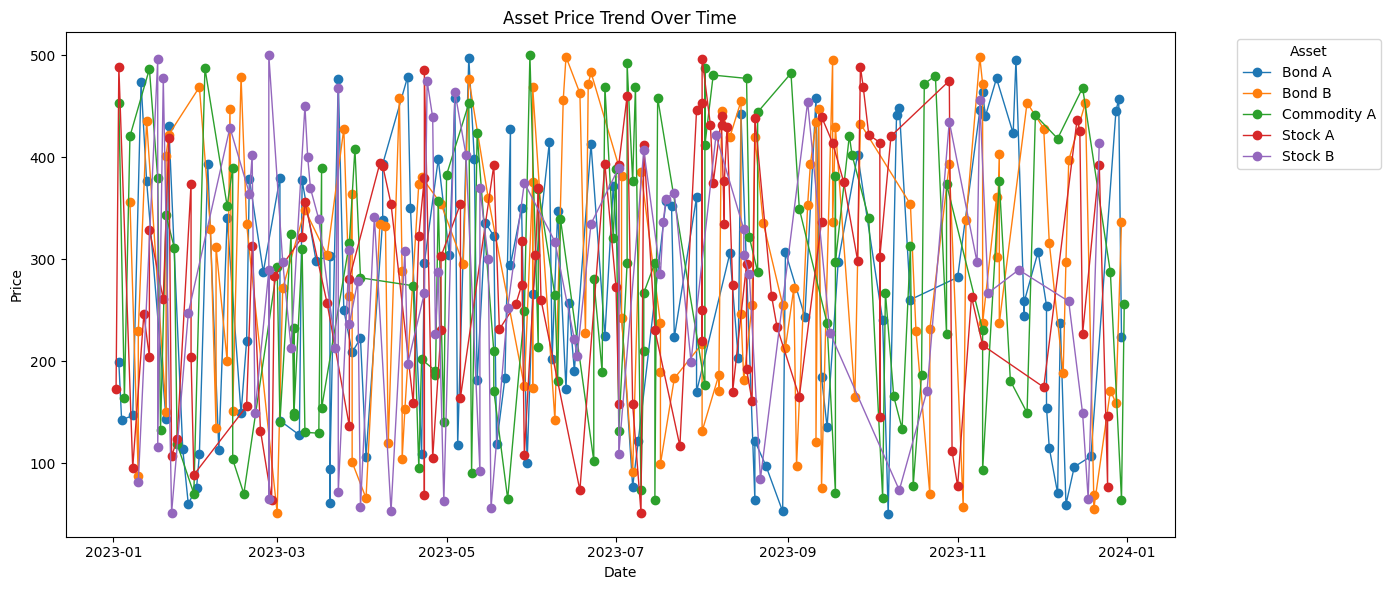

In [9]:
plt.figure(figsize=(14, 6))

for asset in df["asset"].unique():
    asset_data = df[df["asset"] == asset].sort_values("date")
    plt.plot(
        asset_data["date"],
        asset_data["price"],
        linewidth=1,
        marker="o",
        label=asset
    )

plt.title("Asset Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(title="Asset", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_asset_price_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Price Distribution

This histogram shows the overall distribution of asset prices.

Extreme values may be possible anomalies.

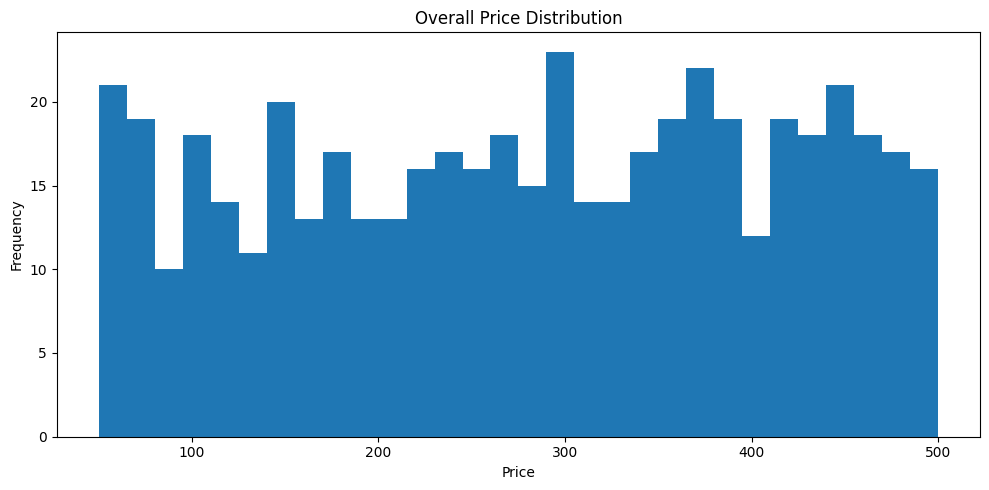

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df["price"].dropna(), bins=30)
plt.title("Overall Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Price Distribution by Asset

A boxplot helps compare price spread for each asset.

Dots or values far away from the box may indicate possible anomalies.

<Figure size 1200x600 with 0 Axes>

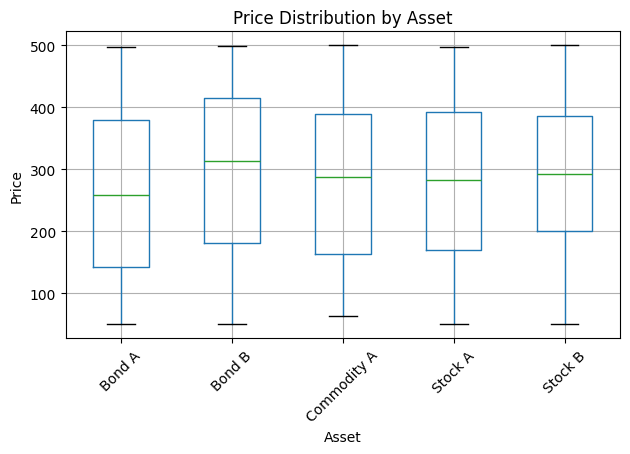

In [11]:
plt.figure(figsize=(12, 6))
df.boxplot(column="price", by="asset", rot=45)
plt.title("Price Distribution by Asset")
plt.suptitle("")
plt.xlabel("Asset")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_price_distribution_by_asset.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Create Anomaly Detection Features

For anomaly detection, raw price alone may not be enough.

We create additional features:

- Daily return
- Price lag features
- Rolling mean
- Rolling standard deviation
- Rolling volatility
- Calendar features

These help machine learning models detect unusual patterns.

In [12]:
def create_anomaly_features(dataframe):
    """
    Create anomaly detection features.

    Args:
        dataframe (pd.DataFrame): Cleaned dataframe.

    Returns:
        pd.DataFrame: Feature-engineered dataframe.
    """
    data = dataframe.copy()
    data = data.sort_values(["asset", "date"]).reset_index(drop=True)

    # Daily return
    data["daily_return"] = (
        data.groupby("asset")["price"]
        .pct_change()
        .replace([np.inf, -np.inf], np.nan)
    )

    data["daily_return"] = data["daily_return"].fillna(0)

    # Lag features
    for lag in [1, 3, 7]:
        data[f"price_lag_{lag}"] = (
            data.groupby("asset")["price"]
            .shift(lag)
        )

    # Rolling features
    for window in [7, 14, 30]:
        data[f"price_rolling_mean_{window}"] = (
            data.groupby("asset")["price"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

        data[f"price_rolling_std_{window}"] = (
            data.groupby("asset")["price"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).std())
        )

        data[f"return_rolling_volatility_{window}"] = (
            data.groupby("asset")["daily_return"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).std())
        )

    # Calendar features
    data["year"] = data["date"].dt.year
    data["month"] = data["date"].dt.month
    data["quarter"] = data["date"].dt.quarter
    data["day"] = data["date"].dt.day
    data["day_of_week"] = data["date"].dt.dayofweek
    data["week_of_year"] = data["date"].dt.isocalendar().week.astype(int)
    data["is_month_start"] = data["date"].dt.is_month_start.astype(int)
    data["is_month_end"] = data["date"].dt.is_month_end.astype(int)

    data = data.replace([np.inf, -np.inf], np.nan)

    numeric_columns = data.select_dtypes(include=["number"]).columns

    for column in numeric_columns:
        if data[column].isna().sum() > 0:
            data[column] = data[column].fillna(data[column].median())

    data = data.fillna(0)

    return data


df_features = create_anomaly_features(df)

print("Feature dataset shape:", df_features.shape)
df_features.head()

Feature dataset shape: (500, 24)


,date,asset,price,daily_return,price_lag_1,price_lag_3,price_lag_7,price_rolling_mean_7,price_rolling_std_7,return_rolling_volatility_7,price_rolling_mean_14,price_rolling_std_14,return_rolling_volatility_14,price_rolling_mean_30,price_rolling_std_30,return_rolling_volatility_30,year,month,quarter,day,day_of_week,week_of_year,is_month_start,is_month_end
0,2023-01-03,Bond A,198.6100,0.0000,289.4100,294.1100,295.0300,198.6100,130.6018,1.0726,198.6100,130.5685,1.2097,198.6100,130.9443,1.3060,2023,1,1,3,1,1,0,0
1,2023-01-04,Bond A,142.2400,-0.2838,198.6100,294.1100,295.0300,170.4250,39.8596,0.2007,170.4250,39.8596,0.2007,170.4250,39.8596,0.2007,2023,1,1,4,2,1,0,0
2,2023-01-08,Bond A,146.5800,0.0305,142.2400,294.1100,295.0300,162.4767,31.3675,0.1733,162.4767,31.3675,0.1733,162.4767,31.3675,0.1733,2023,1,1,8,6,1,0,0
3,2023-01-11,Bond A,473.2000,2.2283,146.5800,198.6100,295.0300,240.1575,157.4586,1.1650,240.1575,157.4586,1.1650,240.1575,157.4586,1.1650,2023,1,1,11,2,2,0,0
4,2023-01-13,Bond A,376.5700,-0.2042,473.2000,142.2400,295.0300,267.4400,149.3873,1.0561,267.4400,149.3873,1.0561,267.4400,149.3873,1.0561,2023,1,1,13,4,2,0,0


## 13. Daily Return Distribution

Daily return shows percentage price change.

Large positive or negative returns may indicate unusual price movements.

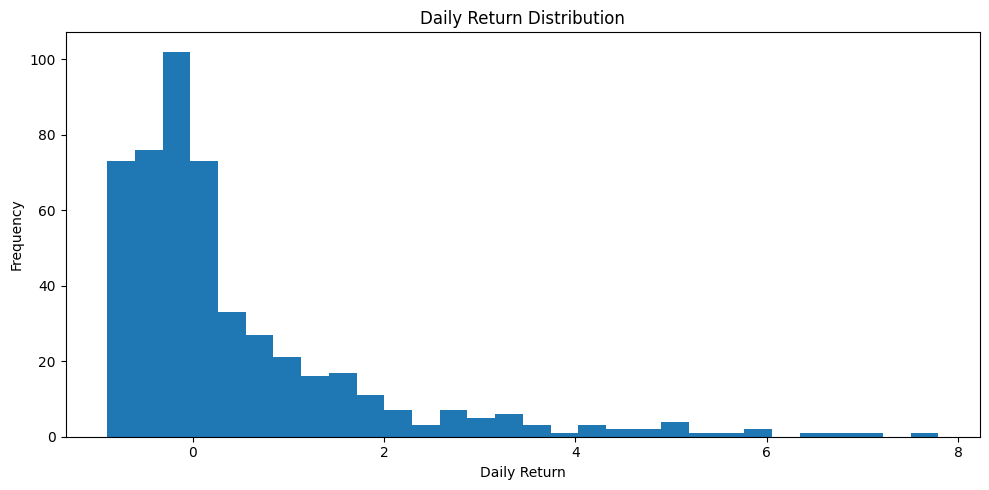

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(df_features["daily_return"].dropna(), bins=30)
plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_daily_return_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. IQR Anomaly Detection

The IQR method identifies values outside the normal price range.

Formula:

```text
IQR = Q3 - Q1
Lower Bound = Q1 - 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR

A price below the lower bound or above the upper bound is marked as an anomaly.

We apply this separately for each asset.

In [14]:
def detect_iqr_anomalies(group, price_column="price", multiplier=1.5):
    """
    Detect IQR anomalies for one asset group.

    Args:
        group (pd.DataFrame): Asset-level dataframe.
        price_column (str): Price column.
        multiplier (float): IQR multiplier.

    Returns:
        pd.DataFrame: Group with IQR anomaly columns.
    """
    group = group.copy()

    q1 = group[price_column].quantile(0.25)
    q3 = group[price_column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr

    group["iqr_q1"] = q1
    group["iqr_q3"] = q3
    group["iqr_value"] = iqr
    group["iqr_lower_bound"] = lower_bound
    group["iqr_upper_bound"] = upper_bound

    group["is_anomaly_iqr"] = (
        (group[price_column] < lower_bound) |
        (group[price_column] > upper_bound)
    )

    return group


df_iqr = (
    df_features.groupby("asset", group_keys=False)
    .apply(detect_iqr_anomalies)
    .reset_index(drop=True)
)

iqr_anomaly_count = int(df_iqr["is_anomaly_iqr"].sum())

print("IQR anomalies detected:", iqr_anomaly_count)

df_iqr[df_iqr["is_anomaly_iqr"]].head()

IQR anomalies detected: 0


,date,price,daily_return,price_lag_1,price_lag_3,price_lag_7,price_rolling_mean_7,price_rolling_std_7,return_rolling_volatility_7,price_rolling_mean_14,price_rolling_std_14,return_rolling_volatility_14,price_rolling_mean_30,price_rolling_std_30,return_rolling_volatility_30,year,month,quarter,day,day_of_week,week_of_year,is_month_start,is_month_end,iqr_q1,iqr_q3,iqr_value,iqr_lower_bound,iqr_upper_bound,is_anomaly_iqr


## 15. Visualize IQR Anomalies

This chart marks IQR anomaly points using `x` markers.

In [17]:
df_returns = df.copy()

df_returns.columns = (
    df_returns.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df_returns["date"] = pd.to_datetime(df_returns["date"])

df_returns = df_returns.sort_values(["asset", "date"])

df_returns["daily_return"] = (
    df_returns.groupby("asset")["price"]
    .pct_change()
    .fillna(0)
)

df_returns.head()

,date,asset,price,daily_return
0,2023-01-03,Bond A,198.6100,0.0000
1,2023-01-04,Bond A,142.2400,-0.2838
2,2023-01-08,Bond A,146.5800,0.0305
3,2023-01-11,Bond A,473.2000,2.2283
4,2023-01-13,Bond A,376.5700,-0.2042


In [18]:
df_iqr = df_returns.copy()

if "asset" not in df_iqr.columns and "asset_name" in df_iqr.columns:
    df_iqr["asset"] = df_iqr["asset_name"]

q1 = df_iqr.groupby("asset")["price"].transform(lambda x: x.quantile(0.25))
q3 = df_iqr.groupby("asset")["price"].transform(lambda x: x.quantile(0.75))

iqr = q3 - q1

df_iqr["iqr_lower_bound"] = q1 - 1.5 * iqr
df_iqr["iqr_upper_bound"] = q3 + 1.5 * iqr

df_iqr["is_anomaly_iqr"] = (
    (df_iqr["price"] < df_iqr["iqr_lower_bound"])
    | (df_iqr["price"] > df_iqr["iqr_upper_bound"])
)

df_iqr.head()

,date,asset,price,daily_return,iqr_lower_bound,iqr_upper_bound,is_anomaly_iqr
0,2023-01-03,Bond A,198.6100,0.0000,-212.4800,733.4400,False
1,2023-01-04,Bond A,142.2400,-0.2838,-212.4800,733.4400,False
2,2023-01-08,Bond A,146.5800,0.0305,-212.4800,733.4400,False
3,2023-01-11,Bond A,473.2000,2.2283,-212.4800,733.4400,False
4,2023-01-13,Bond A,376.5700,-0.2042,-212.4800,733.4400,False


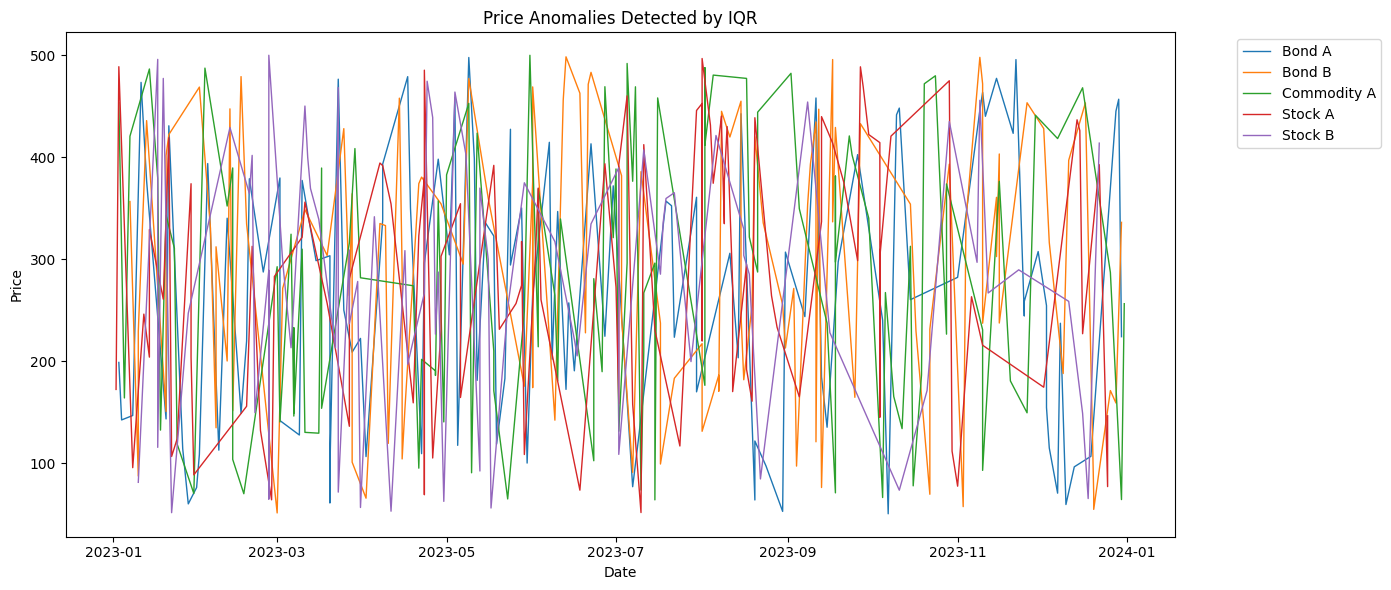

In [19]:
plt.figure(figsize=(14, 6))

for asset in df_iqr["asset"].unique():
    asset_data = df_iqr[df_iqr["asset"] == asset].sort_values("date")
    plt.plot(
        asset_data["date"],
        asset_data["price"],
        linewidth=1,
        label=asset
    )

iqr_anomaly_points = df_iqr[df_iqr["is_anomaly_iqr"]]

if not iqr_anomaly_points.empty:
    plt.scatter(
        iqr_anomaly_points["date"],
        iqr_anomaly_points["price"],
        marker="x",
        s=80,
        label="IQR Anomaly"
    )

plt.title("Price Anomalies Detected by IQR")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_iqr_anomalies.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Z-Score Anomaly Detection

Z-score shows how far a price is from the asset's average price.

Formula:

```text
z_score = (price - mean_price) / standard_deviation

Rule used:

absolute z-score > 3

This means the price is far away from normal values.

In [20]:
def detect_zscore_anomalies(group, price_column="price", threshold=3.0):
    """
    Detect Z-score anomalies for one asset group.

    Args:
        group (pd.DataFrame): Asset-level dataframe.
        price_column (str): Price column.
        threshold (float): Z-score threshold.

    Returns:
        pd.DataFrame: Group with Z-score anomaly columns.
    """
    group = group.copy()

    mean_value = group[price_column].mean()
    std_value = group[price_column].std()

    if std_value == 0 or pd.isna(std_value):
        group["price_z_score"] = 0.0
    else:
        group["price_z_score"] = (
            group[price_column] - mean_value
        ) / std_value

    group["is_anomaly_zscore"] = group["price_z_score"].abs() > threshold

    return group


df_zscore = (
    df_iqr.groupby("asset", group_keys=False)
    .apply(detect_zscore_anomalies)
    .reset_index(drop=True)
)

zscore_anomaly_count = int(df_zscore["is_anomaly_zscore"].sum())

print("Z-score anomalies detected:", zscore_anomaly_count)

df_zscore[df_zscore["is_anomaly_zscore"]].head()

Z-score anomalies detected: 0


,date,price,daily_return,iqr_lower_bound,iqr_upper_bound,is_anomaly_iqr,price_z_score,is_anomaly_zscore


## 17. Visualize Z-Score Anomalies

This chart marks Z-score anomaly points.

In [ ]:
try:
    df_zscore = df_returns.copy()
except NameError:
    df_zscore = df.copy()

# Standardize column names
df_zscore.columns = (
    df_zscore.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)


if "asset" not in df_zscore.columns and "asset_name" in df_zscore.columns:
    df_zscore["asset"] = df_zscore["asset_name"]


required_columns = ["date", "asset", "price"]
missing_columns = [col for col in required_columns if col not in df_zscore.columns]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}. "
        f"Available columns: {df_zscore.columns.tolist()}"
    )


df_zscore["date"] = pd.to_datetime(df_zscore["date"], errors="coerce")
df_zscore["price"] = pd.to_numeric(df_zscore["price"], errors="coerce")

df_zscore = df_zscore.dropna(subset=["date", "asset", "price"])
df_zscore = df_zscore.sort_values(["asset", "date"])


df_zscore["price_mean"] = df_zscore.groupby("asset")["price"].transform("mean")
df_zscore["price_std"] = df_zscore.groupby("asset")["price"].transform("std")

df_zscore["zscore"] = (
    (df_zscore["price"] - df_zscore["price_mean"])
    / df_zscore["price_std"].replace(0, np.nan)
)

df_zscore["zscore"] = df_zscore["zscore"].fillna(0)

# Mark anomalies
df_zscore["is_anomaly_zscore"] = df_zscore["zscore"].abs() > 3

df_zscore.head()

,date,asset,price,daily_return,price_mean,price_std,zscore,is_anomaly_zscore
0,2023-01-03,Bond A,198.6100,0.0000,265.8024,132.7395,-0.5062,False
1,2023-01-04,Bond A,142.2400,-0.2838,265.8024,132.7395,-0.9309,False
2,2023-01-08,Bond A,146.5800,0.0305,265.8024,132.7395,-0.8982,False
3,2023-01-11,Bond A,473.2000,2.2283,265.8024,132.7395,1.5624,False
4,2023-01-13,Bond A,376.5700,-0.2042,265.8024,132.7395,0.8345,False


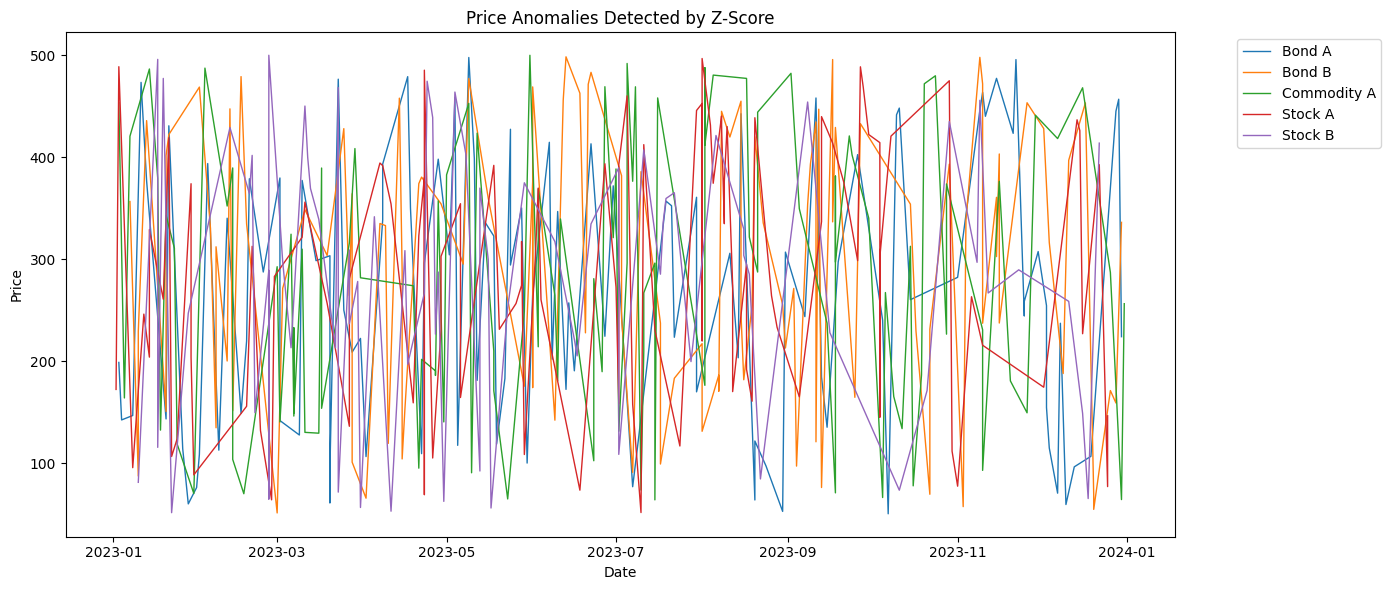

In [27]:
plt.figure(figsize=(14, 6))

for asset in df_zscore["asset"].unique():
    asset_data = df_zscore[df_zscore["asset"] == asset].sort_values("date")
    plt.plot(
        asset_data["date"],
        asset_data["price"],
        linewidth=1,
        label=asset
    )

zscore_anomaly_points = df_zscore[df_zscore["is_anomaly_zscore"]]

if not zscore_anomaly_points.empty:
    plt.scatter(
        zscore_anomaly_points["date"],
        zscore_anomaly_points["price"],
        marker="x",
        s=80,
        label="Z-Score Anomaly"
    )

plt.title("Price Anomalies Detected by Z-Score")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_zscore_anomalies.png", dpi=300, bbox_inches="tight")
plt.show()

## 18. Isolation Forest Anomaly Detection

Isolation Forest is a machine learning anomaly detection algorithm.

It detects unusual records using multiple features, such as:

- Price
- Daily return
- Lag values
- Rolling mean
- Rolling standard deviation
- Rolling volatility
- Calendar features

We train Isolation Forest separately for each asset.

In [28]:
isolation_feature_columns = [
    "price",
    "daily_return",
    "price_lag_1",
    "price_lag_3",
    "price_lag_7",
    "price_rolling_mean_7",
    "price_rolling_std_7",
    "price_rolling_mean_14",
    "price_rolling_std_14",
    "price_rolling_mean_30",
    "price_rolling_std_30",
    "return_rolling_volatility_7",
    "return_rolling_volatility_14",
    "return_rolling_volatility_30",
    "month",
    "quarter",
    "day_of_week",
]

isolation_feature_columns = [
    column for column in isolation_feature_columns
    if column in df_zscore.columns
]

print("Isolation Forest feature columns:")
print(isolation_feature_columns)

Isolation Forest feature columns:
['price', 'daily_return']


In [29]:
def detect_isolation_forest_anomalies(
    dataframe,
    feature_columns,
    contamination=0.05,
    random_state=42
):
    """
    Detect anomalies using Isolation Forest asset-wise.

    Args:
        dataframe (pd.DataFrame): Feature dataframe.
        feature_columns (list): Feature columns.
        contamination (float): Expected anomaly ratio.
        random_state (int): Random seed.

    Returns:
        pd.DataFrame: Dataframe with Isolation Forest anomaly columns.
    """
    output_frames = []

    for asset_name, asset_data in dataframe.groupby("asset"):
        asset_data = asset_data.copy()

        X = asset_data[feature_columns].copy()

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        model = IsolationForest(
            n_estimators=200,
            contamination=contamination,
            random_state=random_state
        )

        isolation_labels = model.fit_predict(X_scaled)
        anomaly_scores = model.decision_function(X_scaled)

        asset_data["isolation_forest_label"] = isolation_labels
        asset_data["is_anomaly_isolation_forest"] = isolation_labels == -1
        asset_data["anomaly_score"] = anomaly_scores

        output_frames.append(asset_data)

    return pd.concat(output_frames, ignore_index=True)


df_isolation = detect_isolation_forest_anomalies(
    dataframe=df_zscore,
    feature_columns=isolation_feature_columns,
    contamination=0.05,
    random_state=42
)

isolation_anomaly_count = int(df_isolation["is_anomaly_isolation_forest"].sum())

print("Isolation Forest anomalies detected:", isolation_anomaly_count)

df_isolation[df_isolation["is_anomaly_isolation_forest"]].head()

Isolation Forest anomalies detected: 27


,date,asset,price,daily_return,price_mean,price_std,zscore,is_anomaly_zscore,isolation_forest_label,is_anomaly_isolation_forest,anomaly_score
26,2023-03-23,Bond A,476.3300,4.0560,265.8024,132.7395,1.5860,False,-1,True,-0.0771
41,2023-05-09,Bond A,497.5900,3.2413,265.8024,132.7395,1.7462,False,-1,True,-0.0729
76,2023-08-31,Bond A,306.7900,4.8381,265.8024,132.7395,0.3088,False,-1,True,-0.1221
85,2023-10-10,Bond A,441.3900,7.7926,265.8024,132.7395,1.3228,False,-1,True,-0.2001
102,2023-12-08,Bond A,237.0200,2.3653,265.8024,132.7395,-0.2168,False,-1,True,-0.0238


## 19. Visualize Isolation Forest Anomalies

This chart marks anomalies detected by Isolation Forest.

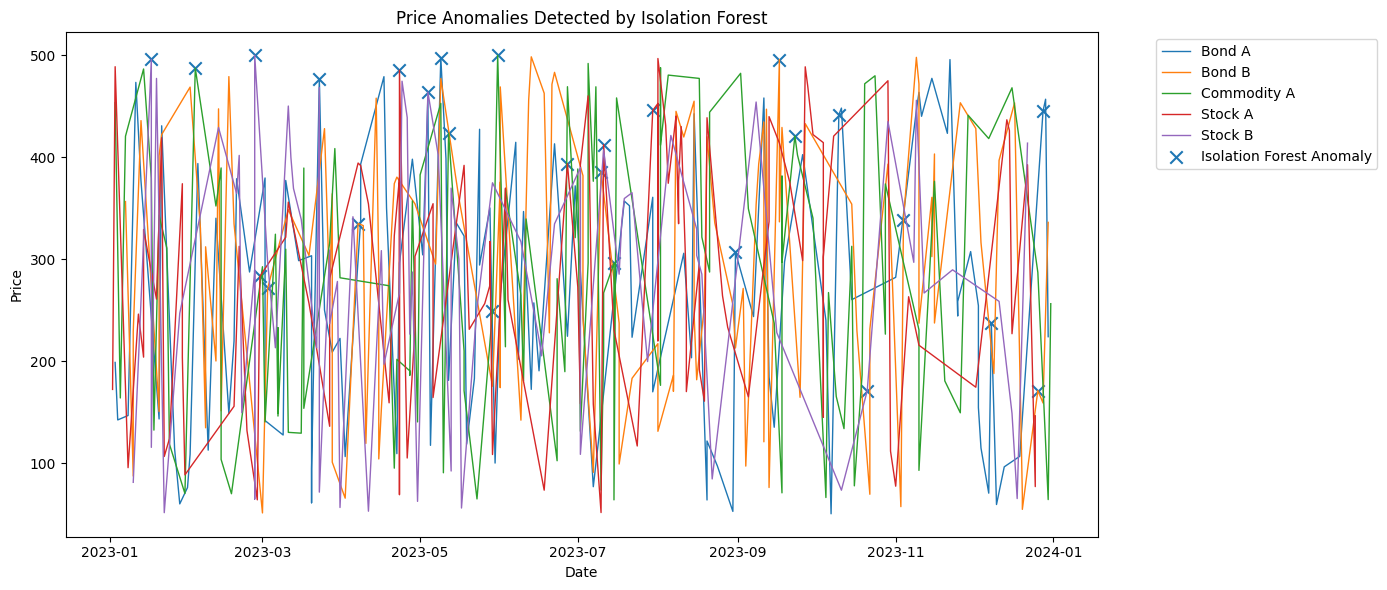

In [30]:
plt.figure(figsize=(14, 6))

for asset in df_isolation["asset"].unique():
    asset_data = df_isolation[df_isolation["asset"] == asset].sort_values("date")
    plt.plot(
        asset_data["date"],
        asset_data["price"],
        linewidth=1,
        label=asset
    )

isolation_anomaly_points = df_isolation[df_isolation["is_anomaly_isolation_forest"]]

if not isolation_anomaly_points.empty:
    plt.scatter(
        isolation_anomaly_points["date"],
        isolation_anomaly_points["price"],
        marker="x",
        s=80,
        label="Isolation Forest Anomaly"
    )

plt.title("Price Anomalies Detected by Isolation Forest")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_isolation_forest_anomalies.png", dpi=300, bbox_inches="tight")
plt.show()

## 20. Combine Anomaly Results

Now we combine all three anomaly detection methods.

A record is considered anomalous if at least one method detects it.

Methods:

- IQR
- Z-score
- Isolation Forest

We also calculate anomaly severity based on how many methods detected the same record.

In [31]:
df_anomaly_results = df_isolation.copy()

anomaly_columns = [
    "is_anomaly_iqr",
    "is_anomaly_zscore",
    "is_anomaly_isolation_forest",
]

for column in anomaly_columns:
    if column not in df_anomaly_results.columns:
        df_anomaly_results[column] = False

df_anomaly_results["anomaly_method_count"] = df_anomaly_results[anomaly_columns].sum(axis=1)

df_anomaly_results["is_anomaly"] = df_anomaly_results["anomaly_method_count"] > 0

def get_anomaly_method(row):
    methods = []

    if row["is_anomaly_iqr"]:
        methods.append("IQR")

    if row["is_anomaly_zscore"]:
        methods.append("Z-Score")

    if row["is_anomaly_isolation_forest"]:
        methods.append("Isolation Forest")

    return ", ".join(methods) if methods else "None"


df_anomaly_results["anomaly_method"] = df_anomaly_results.apply(
    get_anomaly_method,
    axis=1
)

df_anomaly_results["anomaly_severity"] = df_anomaly_results["anomaly_method_count"].map(
    {
        0: "normal",
        1: "low",
        2: "medium",
        3: "high",
    }
)

total_anomalies = int(df_anomaly_results["is_anomaly"].sum())
anomaly_rate = total_anomalies / len(df_anomaly_results) * 100

print("Total records:", len(df_anomaly_results))
print("Total anomalies:", total_anomalies)
print(f"Anomaly rate: {anomaly_rate:.2f}%")

df_anomaly_results.head()

Total records: 500
Total anomalies: 27
Anomaly rate: 5.40%


,date,asset,price,daily_return,price_mean,price_std,zscore,is_anomaly_zscore,isolation_forest_label,is_anomaly_isolation_forest,anomaly_score,is_anomaly_iqr,anomaly_method_count,is_anomaly,anomaly_method,anomaly_severity
0,2023-01-03,Bond A,198.6100,0.0000,265.8024,132.7395,-0.5062,False,1,False,0.1163,False,0,False,None,normal
1,2023-01-04,Bond A,142.2400,-0.2838,265.8024,132.7395,-0.9309,False,1,False,0.1321,False,0,False,None,normal
2,2023-01-08,Bond A,146.5800,0.0305,265.8024,132.7395,-0.8982,False,1,False,0.0932,False,0,False,None,normal
3,2023-01-11,Bond A,473.2000,2.2283,265.8024,132.7395,1.5624,False,1,False,0.0080,False,0,False,None,normal
4,2023-01-13,Bond A,376.5700,-0.2042,265.8024,132.7395,0.8345,False,1,False,0.1192,False,0,False,None,normal


## 21. Final Combined Anomaly Visualization

This chart marks all final anomaly records.

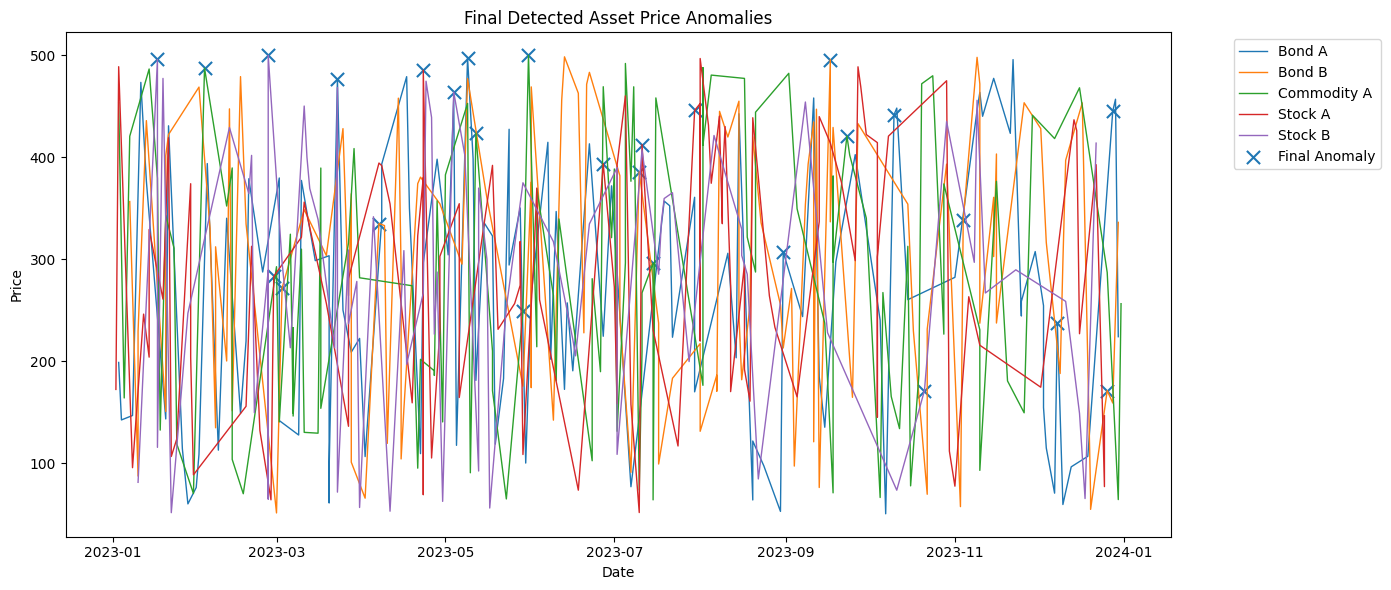

In [32]:
plt.figure(figsize=(14, 6))

for asset in df_anomaly_results["asset"].unique():
    asset_data = df_anomaly_results[df_anomaly_results["asset"] == asset].sort_values("date")
    plt.plot(
        asset_data["date"],
        asset_data["price"],
        linewidth=1,
        label=asset
    )

final_anomaly_points = df_anomaly_results[df_anomaly_results["is_anomaly"]]

if not final_anomaly_points.empty:
    plt.scatter(
        final_anomaly_points["date"],
        final_anomaly_points["price"],
        marker="x",
        s=90,
        label="Final Anomaly"
    )

plt.title("Final Detected Asset Price Anomalies")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_final_anomaly_results.png", dpi=300, bbox_inches="tight")
plt.show()

## 22. Method-wise Anomaly Count

We compare how many anomalies were detected by each method.

In [33]:
method_summary = {
    "IQR": int(df_anomaly_results["is_anomaly_iqr"].sum()),
    "Z-Score": int(df_anomaly_results["is_anomaly_zscore"].sum()),
    "Isolation Forest": int(df_anomaly_results["is_anomaly_isolation_forest"].sum()),
}

method_summary_df = pd.DataFrame(
    list(method_summary.items()),
    columns=["method", "anomaly_count"]
)

method_summary_df

,method,anomaly_count
0,IQR,0
1,Z-Score,0
2,Isolation Forest,27


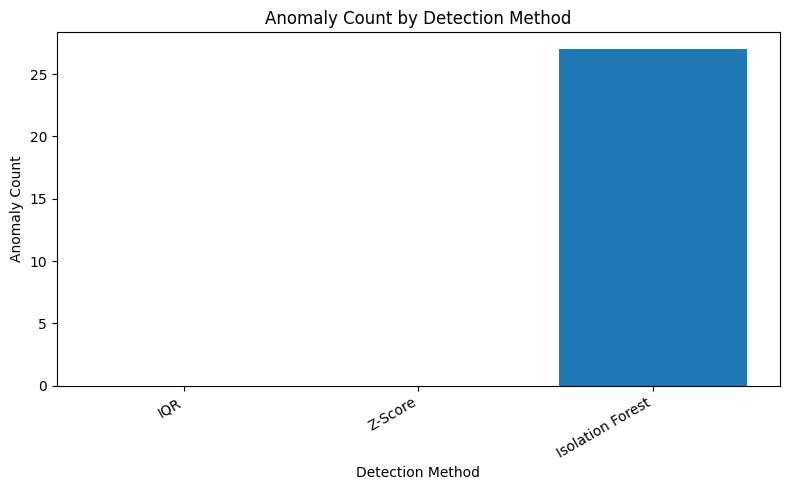

In [34]:
plt.figure(figsize=(8, 5))
plt.bar(method_summary_df["method"], method_summary_df["anomaly_count"])
plt.title("Anomaly Count by Detection Method")
plt.xlabel("Detection Method")
plt.ylabel("Anomaly Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_anomaly_method_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 23. Anomaly Severity Distribution

Severity is based on how many methods detected the same record.

| Method Count | Severity |
|---|---|
| 0 | normal |
| 1 | low |
| 2 | medium |
| 3 | high |

In [35]:
severity_summary = (
    df_anomaly_results["anomaly_severity"]
    .value_counts()
    .reset_index()
)

severity_summary.columns = ["severity", "record_count"]

severity_summary

,severity,record_count
0,normal,473
1,low,27


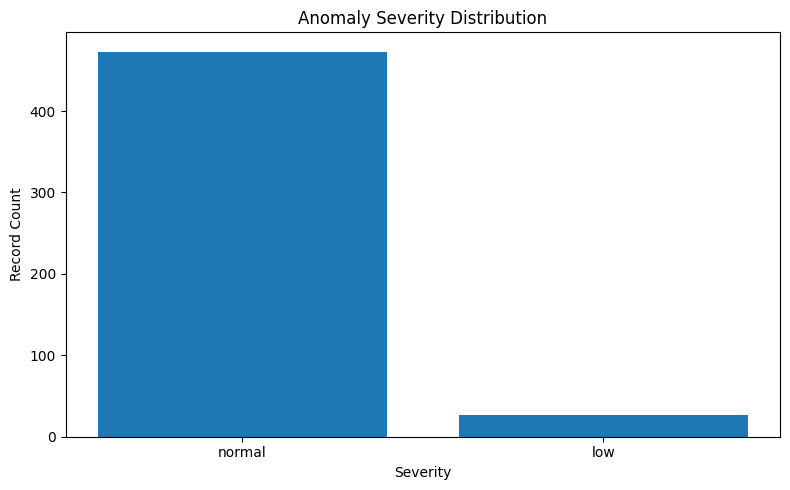

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(severity_summary["severity"], severity_summary["record_count"])
plt.title("Anomaly Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Record Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_anomaly_severity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 24. Asset-wise Anomaly Summary

We summarize anomaly counts for each asset.

In [37]:
asset_anomaly_summary = (
    df_anomaly_results.groupby("asset")
    .agg(
        total_records=("price", "count"),
        anomaly_count=("is_anomaly", "sum"),
        iqr_anomaly_count=("is_anomaly_iqr", "sum"),
        zscore_anomaly_count=("is_anomaly_zscore", "sum"),
        isolation_forest_anomaly_count=("is_anomaly_isolation_forest", "sum"),
        average_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        average_anomaly_score=("anomaly_score", "mean")
    )
    .reset_index()
)

asset_anomaly_summary["anomaly_rate_percent"] = (
    asset_anomaly_summary["anomaly_count"]
    / asset_anomaly_summary["total_records"]
    * 100
)

asset_anomaly_summary = asset_anomaly_summary.sort_values(
    "anomaly_count",
    ascending=False
)

asset_anomaly_summary

,asset,total_records,anomaly_count,iqr_anomaly_count,zscore_anomaly_count,isolation_forest_anomaly_count,average_price,min_price,max_price,average_anomaly_score,anomaly_rate_percent
0,Bond A,109,6,0,0,6,265.8024,50.2000,497.5900,0.0925,5.5046
1,Bond B,110,6,0,0,6,294.4699,51.0400,498.2600,0.1070,5.4545
2,Commodity A,106,6,0,0,6,280.2518,63.8600,499.7600,0.0924,5.6604
3,Stock A,101,5,0,0,5,284.8642,51.4300,496.6000,0.1181,4.9505
4,Stock B,74,4,0,0,4,281.5776,51.3000,499.7900,0.1194,5.4054


## 25. Asset-wise Anomaly Count Chart

This chart shows which assets have the highest number of anomalies.

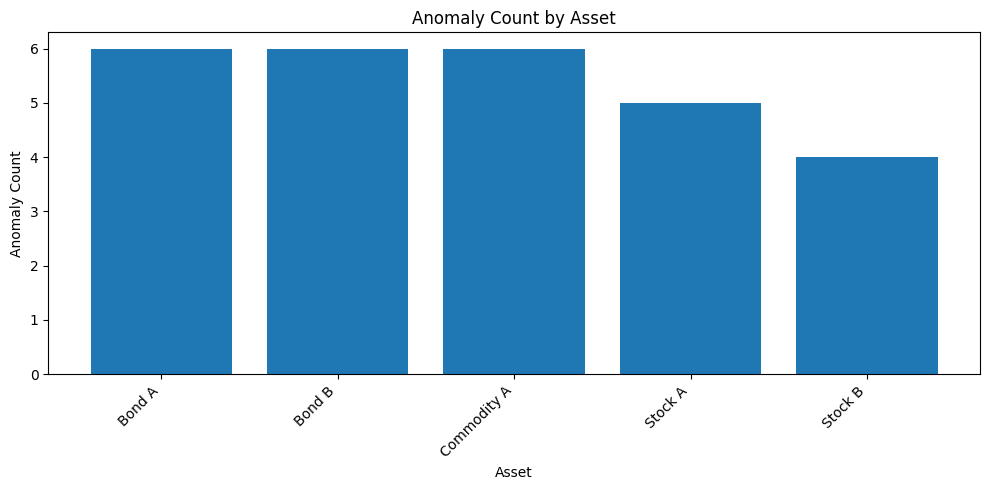

In [38]:
plt.figure(figsize=(10, 5))
plt.bar(asset_anomaly_summary["asset"], asset_anomaly_summary["anomaly_count"])
plt.title("Anomaly Count by Asset")
plt.xlabel("Asset")
plt.ylabel("Anomaly Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_anomaly_count_by_asset.png", dpi=300, bbox_inches="tight")
plt.show()

## 26. Top Anomaly Records

We list the most important anomaly records.

Records detected by more methods are treated as more severe.

In [40]:
if "price_z_score" not in df_anomaly_results.columns:
    if "asset" not in df_anomaly_results.columns and "asset_name" in df_anomaly_results.columns:
        df_anomaly_results["asset"] = df_anomaly_results["asset_name"]

    df_anomaly_results["price_mean"] = (
        df_anomaly_results.groupby("asset")["price"].transform("mean")
    )

    df_anomaly_results["price_std"] = (
        df_anomaly_results.groupby("asset")["price"].transform("std")
    )

    df_anomaly_results["price_z_score"] = (
        (df_anomaly_results["price"] - df_anomaly_results["price_mean"])
        / df_anomaly_results["price_std"].replace(0, np.nan)
    )

    df_anomaly_results["price_z_score"] = df_anomaly_results["price_z_score"].fillna(0)

top_anomaly_records = (
    df_anomaly_results[df_anomaly_results["is_anomaly"]]
    .sort_values(
        by=["anomaly_method_count", "anomaly_score"],
        ascending=[False, True]
    )
    .head(20)
)

top_anomaly_records[
    [
        "date",
        "asset",
        "price",
        "daily_return",
        "price_z_score",
        "anomaly_method",
        "anomaly_severity",
        "anomaly_score"
    ]
]

,date,asset,price,daily_return,price_z_score,anomaly_method,anomaly_severity,anomaly_score
85,2023-10-10,Bond A,441.3900,7.7926,1.3228,Isolation Forest,low,-0.2001
229,2023-02-03,Commodity A,487.1900,5.9549,1.5449,Isolation Forest,low,-0.1791
188,2023-09-17,Bond B,495.5900,5.5226,1.5272,Isolation Forest,low,-0.1666
378,2023-07-11,Stock A,412.1400,7.0136,1.0155,Isolation Forest,low,-0.1508
355,2023-04-23,Stock A,485.1700,6.0284,1.5981,Isolation Forest,low,-0.1354
76,2023-08-31,Bond A,306.7900,4.8381,0.3088,Isolation Forest,low,-0.1221
300,2023-09-23,Commodity A,420.7000,4.9480,1.0485,Isolation Forest,low,-0.0952
438,2023-02-26,Stock B,499.7900,6.7271,1.6572,Isolation Forest,low,-0.0855
126,2023-03-03,Bond B,271.3700,4.3168,-0.1754,Isolation Forest,low,-0.0785
26,2023-03-23,Bond A,476.3300,4.0560,1.5860,Isolation Forest,low,-0.0771


## 27. Asset-wise Detailed Anomaly Charts

We create a separate chart for each asset.

This makes it easier to inspect anomaly behavior asset by asset.

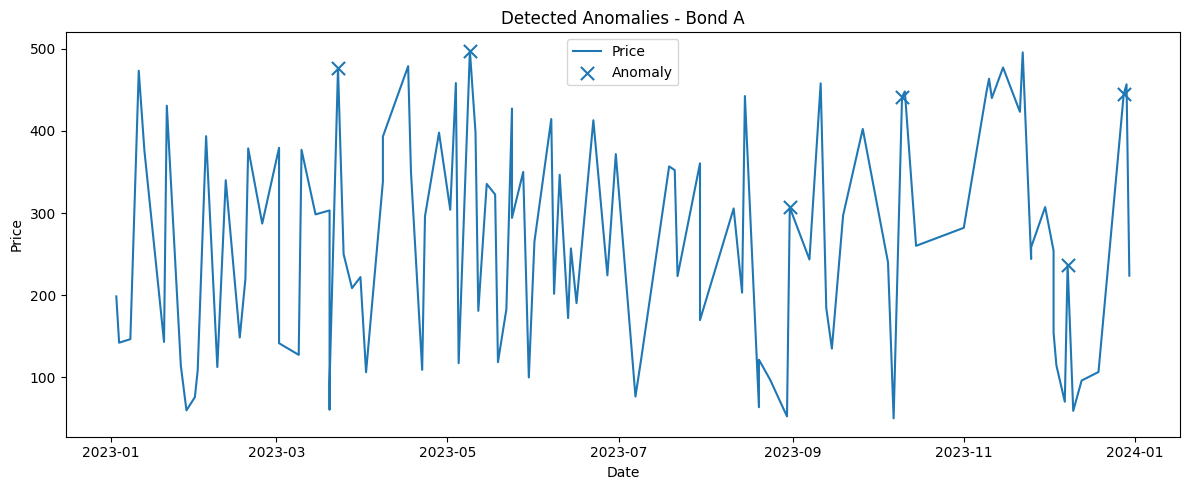

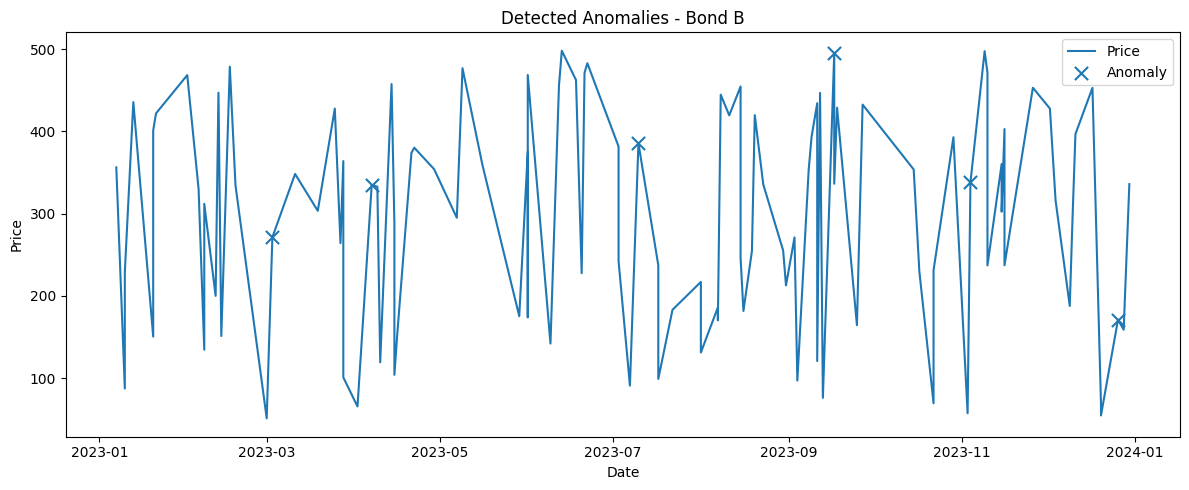

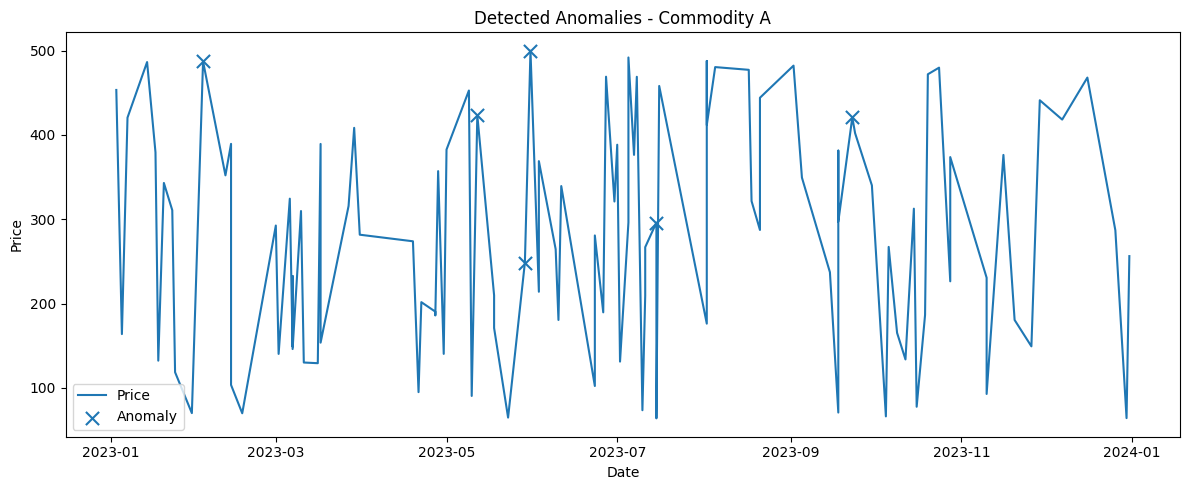

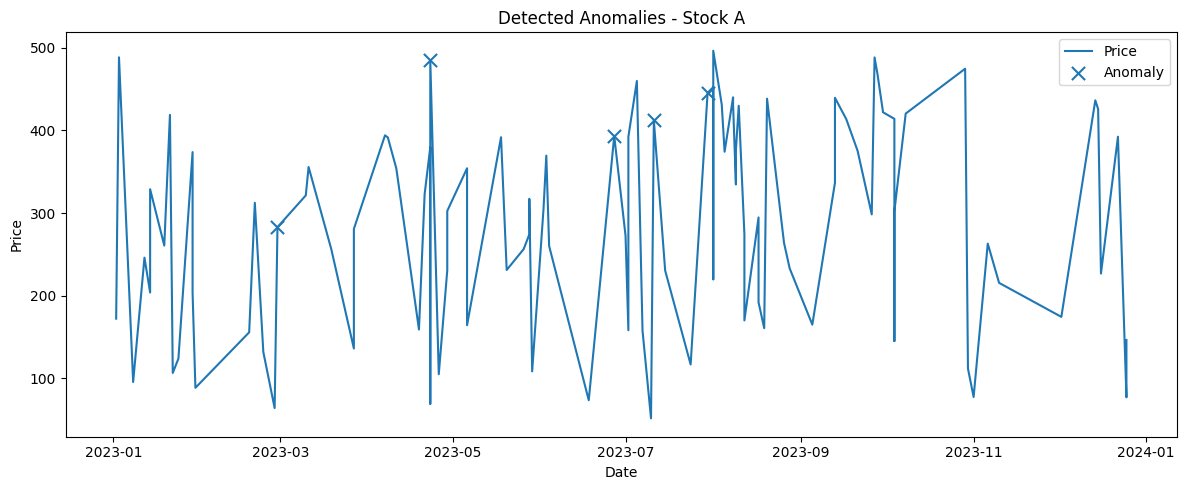

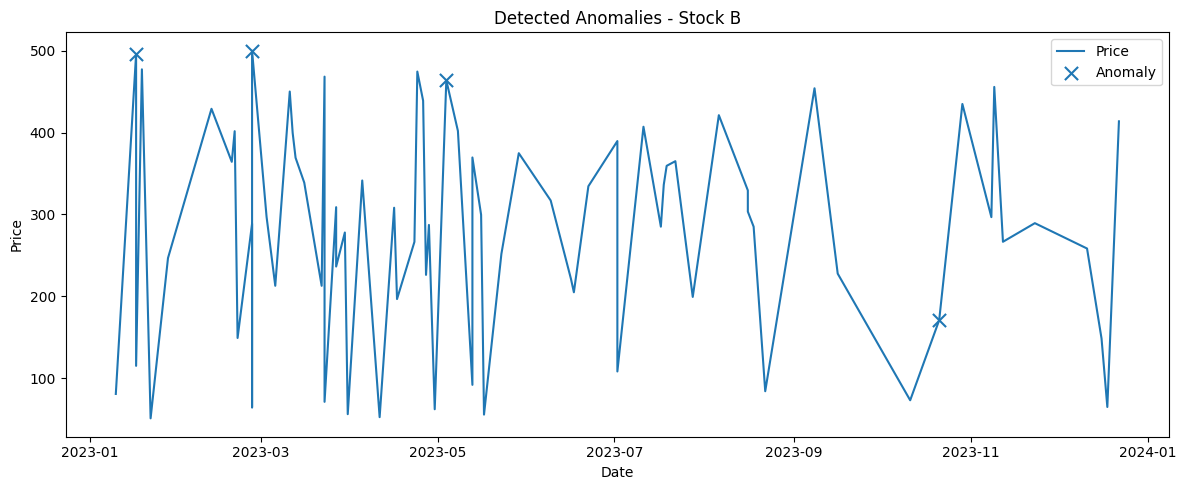

In [41]:
for asset in df_anomaly_results["asset"].unique():
    asset_data = df_anomaly_results[
        df_anomaly_results["asset"] == asset
    ].sort_values("date")

    asset_anomalies = asset_data[asset_data["is_anomaly"]]

    plt.figure(figsize=(12, 5))

    plt.plot(
        asset_data["date"],
        asset_data["price"],
        linewidth=1.5,
        label="Price"
    )

    if not asset_anomalies.empty:
        plt.scatter(
            asset_anomalies["date"],
            asset_anomalies["price"],
            marker="x",
            s=90,
            label="Anomaly"
        )

    plt.title(f"Detected Anomalies - {asset}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()

    safe_asset_name = str(asset).replace(" ", "_").replace("/", "_").lower()

    plt.savefig(
        FIGURES_DIR / f"04_anomalies_{safe_asset_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 28. Anomaly Score Distribution

Isolation Forest produces anomaly scores.

Lower scores usually indicate more unusual records.

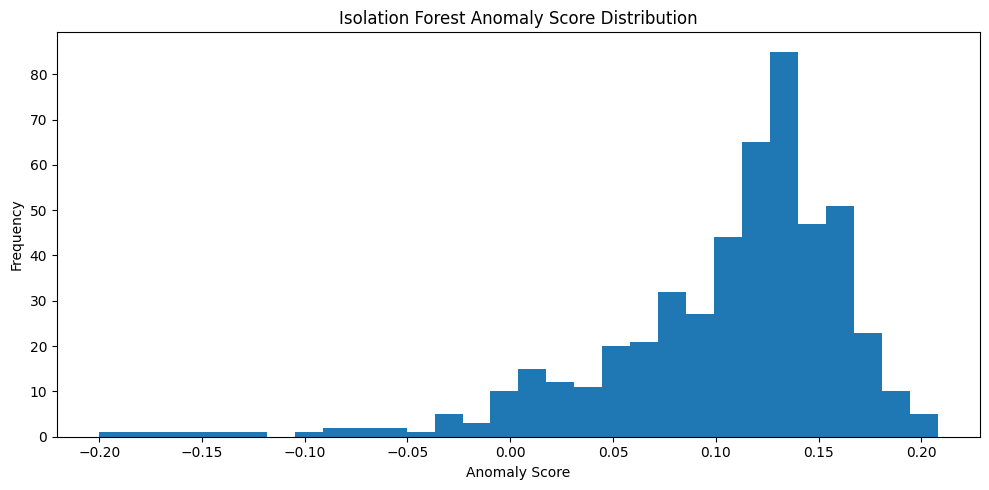

In [42]:
plt.figure(figsize=(10, 5))
plt.hist(df_anomaly_results["anomaly_score"].dropna(), bins=30)
plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_anomaly_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 29. Save Anomaly Detection Outputs

We save:

- Final anomaly result dataset
- Method summary
- Severity summary
- Asset-wise anomaly summary
- Top anomaly records
- Overall anomaly summary JSON

In [43]:
final_output_columns = [
    "date",
    "asset",
    "price",
    "daily_return",
    "price_z_score",
    "is_anomaly_iqr",
    "is_anomaly_zscore",
    "is_anomaly_isolation_forest",
    "anomaly_method_count",
    "is_anomaly",
    "anomaly_method",
    "anomaly_severity",
    "anomaly_score",
]

available_output_columns = [
    column for column in final_output_columns
    if column in df_anomaly_results.columns
]

final_anomaly_output = df_anomaly_results[available_output_columns].copy()

final_anomaly_output.to_csv(
    OUTPUTS_DIR / "04_anomaly_detection_results.csv",
    index=False
)

df_anomaly_results.to_csv(
    OUTPUTS_DIR / "04_full_anomaly_detection_results.csv",
    index=False
)

method_summary_df.to_csv(
    TABLES_DIR / "04_anomaly_method_summary.csv",
    index=False
)

severity_summary.to_csv(
    TABLES_DIR / "04_anomaly_severity_summary.csv",
    index=False
)

asset_anomaly_summary.to_csv(
    TABLES_DIR / "04_asset_anomaly_summary.csv",
    index=False
)

top_anomaly_records.to_csv(
    TABLES_DIR / "04_top_anomaly_records.csv",
    index=False
)

anomaly_summary = {
    "total_records": int(len(df_anomaly_results)),
    "total_anomalies": int(total_anomalies),
    "anomaly_rate_percent": round(float(anomaly_rate), 4),
    "asset_count": int(df_anomaly_results["asset"].nunique()),
    "method_summary": method_summary,
    "severity_summary": severity_summary.to_dict(orient="records"),
    "feature_columns": isolation_feature_columns,
}

with open(TABLES_DIR / "04_anomaly_summary.json", "w", encoding="utf-8") as file:
    json.dump(anomaly_summary, file, indent=4)

print("Saved anomaly detection outputs:")
print(OUTPUTS_DIR / "04_anomaly_detection_results.csv")
print(OUTPUTS_DIR / "04_full_anomaly_detection_results.csv")
print(TABLES_DIR / "04_anomaly_method_summary.csv")
print(TABLES_DIR / "04_anomaly_severity_summary.csv")
print(TABLES_DIR / "04_asset_anomaly_summary.csv")
print(TABLES_DIR / "04_top_anomaly_records.csv")
print(TABLES_DIR / "04_anomaly_summary.json")

Saved anomaly detection outputs:
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\outputs\04_anomaly_detection_results.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\outputs\04_full_anomaly_detection_results.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\04_anomaly_method_summary.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\04_anomaly_severity_summary.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\04_asset_anomaly_summary.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\04_top_anomaly_records.csv
e:\VS CODE\The Developer's Arena Int

## 30. Use Project Anomaly Detector Class

Your project also contains a production-style anomaly detector:

```text
src/models/anomaly_detector.py

In [45]:
try:
    import sys
    import pandas as pd
    from pathlib import Path

    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))

    from src.models.anomaly_detector import FinancialAnomalyDetector

    # Make a safe copy of df
    df_project_anomaly = df.copy()

    # Standardize column names
    df_project_anomaly.columns = (
        df_project_anomaly.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

    # Fix asset column issue
    if "asset" not in df_project_anomaly.columns and "asset_name" in df_project_anomaly.columns:
        df_project_anomaly["asset"] = df_project_anomaly["asset_name"]

    # Fix price column issue if needed
    if "price" not in df_project_anomaly.columns and "asset_value" in df_project_anomaly.columns:
        df_project_anomaly["price"] = df_project_anomaly["asset_value"]

    # Convert date and price safely
    df_project_anomaly["date"] = pd.to_datetime(
        df_project_anomaly["date"],
        errors="coerce"
    )

    df_project_anomaly["price"] = pd.to_numeric(
        df_project_anomaly["price"],
        errors="coerce"
    )

    # Drop invalid rows
    df_project_anomaly = df_project_anomaly.dropna(
        subset=["date", "asset", "price"]
    )

    # Confirm required columns
    required_columns = ["date", "asset", "price"]
    missing_columns = [
        column for column in required_columns
        if column not in df_project_anomaly.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing columns: {missing_columns}. "
            f"Available columns: {df_project_anomaly.columns.tolist()}"
        )

    project_detector = FinancialAnomalyDetector(
        date_column="date",
        asset_column="asset",
        target_column="price",
        iqr_multiplier=1.5,
        z_score_threshold=3.0,
        contamination=0.05,
        random_state=42
    )

    project_anomaly_summary = project_detector.fit_detect_save(df_project_anomaly)

    print("Project anomaly detector completed successfully.")
    project_anomaly_summary

except Exception as error:
    print("Project anomaly detector optional run skipped.")
    print("Reason:", error)

2026-06-08 14:54:43,460 - financial_portfolio - INFO - Starting complete anomaly detection workflow.


2026-06-08 14:54:43,638 - financial_portfolio - INFO - IQR anomaly detection completed. Detected anomalies: 0
2026-06-08 14:54:43,657 - financial_portfolio - INFO - Z-score anomaly detection completed. Detected anomalies: 0


Project anomaly detector optional run skipped.
Reason: 'asset'


## 31. Key Observations

### IQR Anomaly Detection

- IQR method detects prices outside the normal interquartile range.
- It is simple and explainable.
- It works well for detecting extreme price values.

### Z-Score Anomaly Detection

- Z-score detects prices far from the asset average.
- It is useful when price distribution is close to normal.
- It may miss anomalies if the distribution is highly skewed.

### Isolation Forest

- Isolation Forest uses multiple features.
- It can detect unusual patterns beyond simple high or low price.
- It is useful for complex anomaly detection.

### Combined Method

- Combining multiple methods gives stronger anomaly detection.
- If multiple methods detect the same record, the anomaly is more serious.
- Severity helps prioritize which anomalies should be reviewed first.

## 32. Final Anomaly Detection Experiment Summary

### What We Completed

In this notebook, we:

- Loaded and cleaned the financial asset price dataset
- Created anomaly detection features
- Applied IQR anomaly detection
- Applied Z-score anomaly detection
- Applied Isolation Forest anomaly detection
- Combined all anomaly flags
- Created anomaly severity levels
- Generated asset-wise anomaly summaries
- Visualized anomaly records
- Saved final anomaly outputs

### Key Outputs

```text
outputs/04_anomaly_detection_results.csv
outputs/04_full_anomaly_detection_results.csv
reports/tables/04_anomaly_method_summary.csv
reports/tables/04_anomaly_severity_summary.csv
reports/tables/04_asset_anomaly_summary.csv
reports/tables/04_top_anomaly_records.csv
reports/tables/04_anomaly_summary.json
reports/figures/04_final_anomaly_results.png
reports/figures/04_anomaly_count_by_asset.png
reports/figures/04_anomaly_method_comparison.png

## 33. Business Interpretation

This anomaly detection system can help identify:

- Sudden asset price jumps
- Sudden asset price drops
- Unusual market behavior
- Possible data quality issues
- Assets requiring closer monitoring